# Credit Risk Prediction

## Objective
Build a machine learning model to predict whether a customer will default on a loan.

## Problem Type
Binary Classification  
Target Variable: Risk (1 = Default, 0 = Non-Default)

## Business Impact
Accurate default prediction helps:
- Reduce financial losses
- Improve loan approval decisions
- Optimize interest rates


In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
column_names = [
    "Status", "Duration", "CreditHistory", "Purpose",
    "CreditAmount", "Savings", "EmploymentDuration",
    "InstallmentRate", "PersonalStatusSex", "OtherDebtors",
    "ResidenceDuration", "Property", "Age",
    "OtherInstallmentPlans", "Housing", "ExistingCredits",
    "Job", "NumberOfDependents", "Telephone",
    "ForeignWorker", "Risk"
]

df = pd.read_csv(
    "german.data",
    sep=" ",
    header=None,
    names=column_names
)

df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentDuration,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,NumberOfDependents,Telephone,ForeignWorker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
df["Risk"] = df["Risk"].map({1: 0, 2: 1})
df["Risk"].value_counts()

Risk
0    700
1    300
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Status                 1000 non-null   str  
 1   Duration               1000 non-null   int64
 2   CreditHistory          1000 non-null   str  
 3   Purpose                1000 non-null   str  
 4   CreditAmount           1000 non-null   int64
 5   Savings                1000 non-null   str  
 6   EmploymentDuration     1000 non-null   str  
 7   InstallmentRate        1000 non-null   int64
 8   PersonalStatusSex      1000 non-null   str  
 9   OtherDebtors           1000 non-null   str  
 10  ResidenceDuration      1000 non-null   int64
 11  Property               1000 non-null   str  
 12  Age                    1000 non-null   int64
 13  OtherInstallmentPlans  1000 non-null   str  
 14  Housing                1000 non-null   str  
 15  ExistingCredits        1000 non-null   int64
 16  

In [5]:
y = df["Risk"]
X = df.drop(columns=["Risk"])

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)


Original shape: (1000, 20)
Encoded shape: (1000, 48)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (750, 48)
Test shape: (250, 48)


In [7]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.764
ROC-AUC: 0.7854095238095237

Confusion Matrix:
[[163  12]
 [ 47  28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       175
           1       0.70      0.37      0.49        75

    accuracy                           0.76       250
   macro avg       0.74      0.65      0.67       250
weighted avg       0.75      0.76      0.74       250



In [10]:
threshold = 0.3

y_pred_adjusted = (y_prob >= threshold).astype(int)

print("New Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

print("\nNew Classification Report:")
print(classification_report(y_test, y_pred_adjusted))

New Confusion Matrix:
[[112  63]
 [ 16  59]]

New Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74       175
           1       0.48      0.79      0.60        75

    accuracy                           0.68       250
   macro avg       0.68      0.71      0.67       250
weighted avg       0.76      0.68      0.70       250



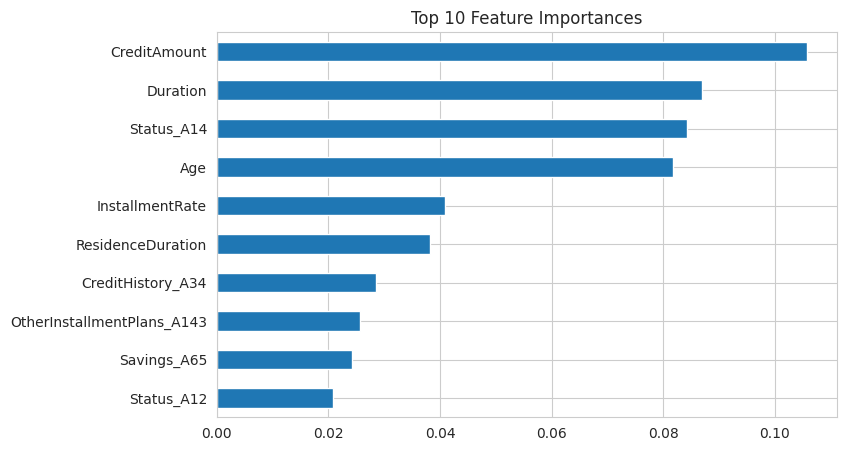

CreditAmount                  0.105793
Duration                      0.086959
Status_A14                    0.084180
Age                           0.081736
InstallmentRate               0.040814
ResidenceDuration             0.038283
CreditHistory_A34             0.028599
OtherInstallmentPlans_A143    0.025694
Savings_A65                   0.024184
Status_A12                    0.020826
dtype: float64

In [11]:
importances = pd.Series(model.named_steps["clf"].feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

top_features


In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


Accuracy: 0.74
ROC-AUC: 0.8052571428571429

Confusion Matrix:
[[126  49]
 [ 16  59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.79       175
           1       0.55      0.79      0.64        75

    accuracy                           0.74       250
   macro avg       0.72      0.75      0.72       250
weighted avg       0.79      0.74      0.75       250



In [13]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Performance")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


XGBoost Performance
Accuracy: 0.776
ROC-AUC: 0.8093714285714286

Confusion Matrix:
[[156  19]
 [ 37  38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       175
           1       0.67      0.51      0.58        75

    accuracy                           0.78       250
   macro avg       0.74      0.70      0.71       250
weighted avg       0.77      0.78      0.77       250



In [14]:
rf_auc = roc_auc_score(y_test, y_prob)
lr_auc = roc_auc_score(y_test, lr_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Model Comparison (single split ROC-AUC, reference only)")
print("Random Forest:", rf_auc)
print("Logistic Regression:", lr_auc)
print("XGBoost:", xgb_auc)


Model Comparison (single split ROC-AUC, reference only)
Random Forest: 0.7854095238095237
Logistic Regression: 0.8052571428571429
XGBoost: 0.8093714285714286


In [15]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [16]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest CV ROC-AUC Scores:", rf_cv_scores)
print("Mean ROC-AUC:", rf_cv_scores.mean())
print("Std Dev:", rf_cv_scores.std())


Random Forest CV ROC-AUC Scores: [0.79297619 0.73839286 0.7547619  0.82255952 0.79261905]
Mean ROC-AUC: 0.7802619047619048
Std Dev: 0.030022350895424252


In [17]:
lr_cv_scores = cross_val_score(
    lr_model,
    X_encoded,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC Scores:", lr_cv_scores)
print("Mean ROC-AUC:", lr_cv_scores.mean())
print("Std Dev:", lr_cv_scores.std())


Logistic Regression CV ROC-AUC Scores: [0.76297619 0.75238095 0.78083333 0.80261905 0.80392857]
Mean ROC-AUC: 0.780547619047619
Std Dev: 0.020668888403729033


In [18]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_encoded,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost CV ROC-AUC Scores:", xgb_cv_scores)
print("Mean ROC-AUC:", xgb_cv_scores.mean())
print("Std Dev:", xgb_cv_scores.std())


XGBoost CV ROC-AUC Scores: [0.77297619 0.75833333 0.77321429 0.81654762 0.79416667]
Mean ROC-AUC: 0.783047619047619
Std Dev: 0.02027218417554374


In [19]:
cv_results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Mean ROC-AUC": [
        np.mean(lr_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(xgb_cv_scores)
    ],
    "Std Dev": [
        np.std(lr_cv_scores),
        np.std(rf_cv_scores),
        np.std(xgb_cv_scores)
    ]
})

cv_results_df

# In[]

models_by_name = {
    "Logistic Regression": lr_model,
    "Random Forest": model,
    "XGBoost": xgb_model
}

best_model_name = cv_results_df.loc[cv_results_df["Mean ROC-AUC"].idxmax(), "Model"]
best_model = models_by_name[best_model_name]

print("Best Model Selected (by CV mean ROC-AUC):", best_model_name)
print("CV Mean ROC-AUC:", cv_results_df["Mean ROC-AUC"].max())


Best Model Selected (by CV mean ROC-AUC): XGBoost
CV Mean ROC-AUC: 0.783047619047619


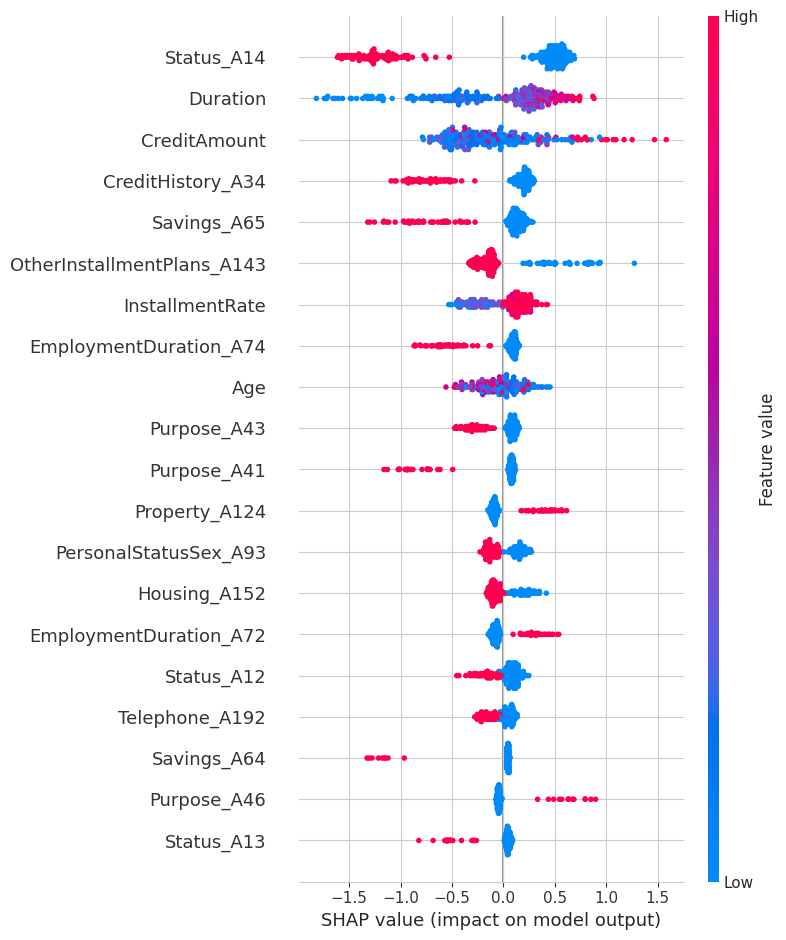

In [20]:
import shap

def get_shap_explainer(pipeline, model_name, X_train_raw):
    clf = pipeline.named_steps["clf"]
    X_train_scaled = pipeline.named_steps["scaler"].transform(X_train_raw)
    if model_name in ("Random Forest", "XGBoost"):
        return shap.TreeExplainer(clf), X_train_scaled
    elif model_name == "Logistic Regression":
        return shap.LinearExplainer(clf, X_train_scaled), X_train_scaled
    else:
        raise ValueError(f"No SHAP explainer mapped for model: {model_name}")

explainer, _ = get_shap_explainer(best_model, best_model_name, X_train)
X_test_scaled = best_model.named_steps["scaler"].transform(X_test)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)
